# **Fraud Transaction Detection System**

1.   This project focuses on detecting fraudulent transactions using machine learning techniques.
2.   The goal is to identify suspicious activities and provide actionable business insights to reduce financial loss.



In [1]:
# ================================
# Import Required Libraries
# ================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

**Dataset Understanding**

In [2]:
# ================================
# Load Dataset
# ================================

df = pd.read_csv("fraud_transactions_dataset.csv")

# View first 5 rows
df.head(5)

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Hour,Location,Merchant_Category,Payment_Method,Device_Type,Is_Fraud
0,T1,1102,2623.20,4,Hyderabad,Entertainment,UPI,Mobile,0
1,T2,1179,4112.53,22,Hyderabad,Grocery,Card,Mobile,0
2,T3,1092,268.21,18,Bangalore,Electronics,Card,Tablet,0
3,T4,1014,3469.85,19,Nagpur,Fashion,UPI,Mobile,0
4,T5,1106,3297.44,13,Bangalore,Grocery,UPI,Mobile,0


In [3]:
# Shape of dataset (rows, columns)
df.shape

(3000, 9)

In [4]:
# Column names
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Amount',
       'Transaction_Hour', 'Location', 'Merchant_Category', 'Payment_Method',
       'Device_Type', 'Is_Fraud'],
      dtype='object')

In [5]:
# ================================
# Check Missing Values
# ================================

df.isnull().sum()

,0
Transaction_ID,0
Customer_ID,0
Transaction_Amount,0
Transaction_Hour,0
Location,0
Merchant_Category,0
Payment_Method,0
Device_Type,0
Is_Fraud,0


In [6]:
# Percentage of missing values
(df.isnull().sum() / len(df)) * 100

,0
Transaction_ID,0.0
Customer_ID,0.0
Transaction_Amount,0.0
Transaction_Hour,0.0
Location,0.0
Merchant_Category,0.0
Payment_Method,0.0
Device_Type,0.0
Is_Fraud,0.0


In [7]:
# ================================
# Statistical Summary
# ================================

df.describe(include='all')

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Hour,Location,Merchant_Category,Payment_Method,Device_Type,Is_Fraud
count,3000,3000.000000,3000.000000,3000.000000,3000,3000,3000,3000,3000.000000
unique,3000,NaN,NaN,NaN,8,6,3,3,NaN
top,T3000,NaN,NaN,NaN,Delhi,Fashion,Card,Mobile,NaN
freq,1,NaN,NaN,NaN,409,536,1370,1944,NaN
mean,NaN,1099.153333,3903.634157,11.383000,NaN,NaN,NaN,NaN,0.086000
std,NaN,58.046059,3885.626701,6.898612,NaN,NaN,NaN,NaN,0.280411
min,NaN,1000.000000,0.050000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,NaN,1048.000000,1140.992500,5.000000,NaN,NaN,NaN,NaN,0.000000
50%,NaN,1101.000000,2712.485000,11.000000,NaN,NaN,NaN,NaN,0.000000
75%,NaN,1149.000000,5417.895000,17.000000,NaN,NaN,NaN,NaN,0.000000


**Exploratory Data Analysis (EDA)**

In [8]:
# ================================
# Fraud vs Normal Transactions
# ================================

df['Is_Fraud'].value_counts()


,count
Is_Fraud,
0,2742
1,258


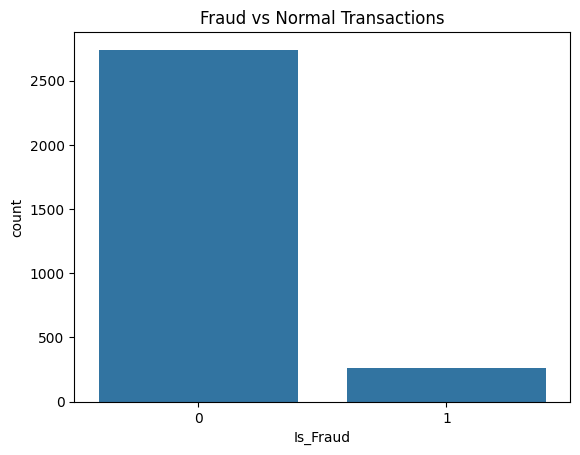

In [9]:
sns.countplot(x='Is_Fraud', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

Insight
0 → Normal transaction
1 → Fraud transaction

Fraud transactions are usually very small compared to normal transactions.

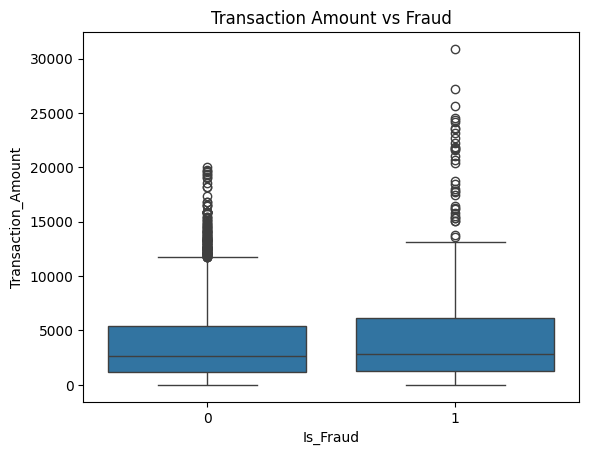

In [10]:
# ================================
# Fraud Transaction Amount Pattern
# ================================

sns.boxplot(x='Is_Fraud', y='Transaction_Amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

Insight

Fraud transactions may contain higher or abnormal amounts.

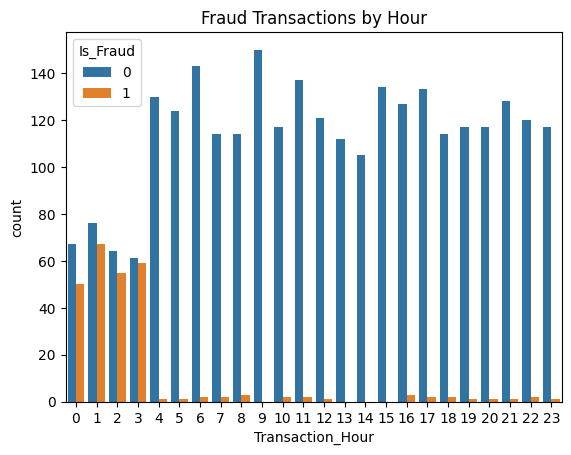

In [11]:
# ================================
# Fraud by Transaction Hour
# ================================

sns.countplot(x='Transaction_Hour', hue='Is_Fraud', data=df)
plt.title("Fraud Transactions by Hour")
plt.show()

Insight

Fraud transactions often happen late night (1 AM – 4 AM).

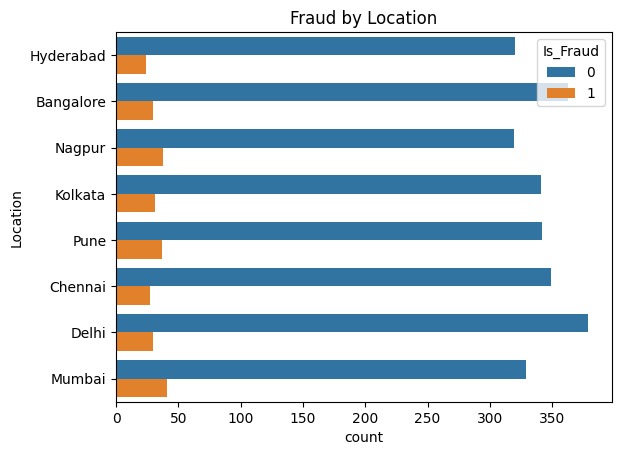

In [12]:
# ================================
# Fraud by Location
# ================================

sns.countplot(y='Location', hue='Is_Fraud', data=df)
plt.title("Fraud by Location")
plt.show()

Insight

Some locations may show higher fraud frequency.

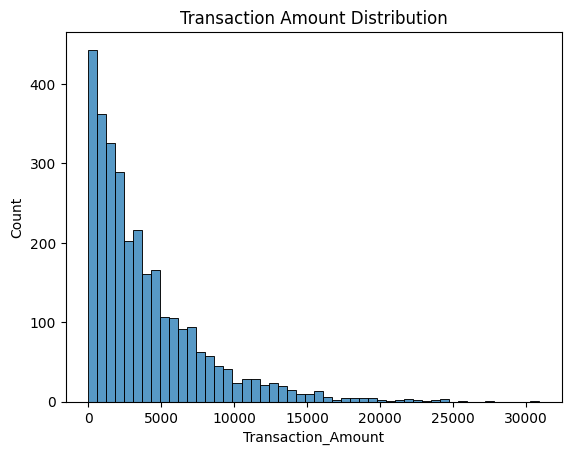

In [13]:
# ================================
# Transaction Amount Distribution
# ================================

sns.histplot(df['Transaction_Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

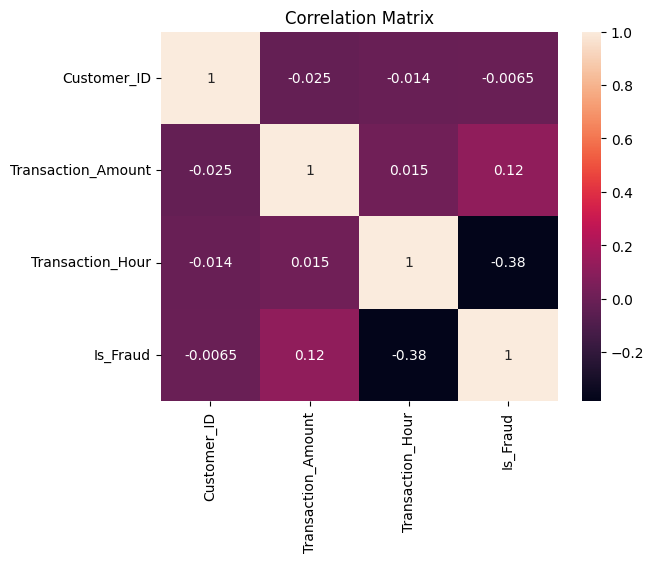

In [14]:
# ================================
# Correlation Analysis
# ================================

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

**Feature Engineering**

In [15]:
# ================================
# Average Customer Spending
# ================================

df['avg_customer_spending'] = df.groupby('Customer_ID')['Transaction_Amount'].transform('mean')

In [16]:
# ================================
# Abnormal Transaction Feature
# ================================

df['abnormal_transaction'] = (df['Transaction_Amount'] > df['avg_customer_spending']).astype(int)

Meaning:

1 → abnormal transaction
0 → normal

In [17]:
# ================================
# Night Transaction Feature
# ================================

df['night_transaction'] = df['Transaction_Hour'].apply(lambda x: 1 if x >= 0 and x <= 5 else 0)

Fraud often happens late night.

In [21]:
df.to_csv('processed_data.csv', index=False)

# Save the file
# It connects preprocessing → modeling